Using Colab cache for faster access to the 'face-expression-recognition-dataset' dataset.
Device: cuda
Total combinations: 2

Run #1  Config: {'batch_size': 128, 'num_epochs': 10, 'lr': 0.001}


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

  Epoch 1/10  Train Acc: 53.25%
  Epoch 2/10  Train Acc: 58.49%
  Epoch 3/10  Train Acc: 59.82%
  Epoch 4/10  Train Acc: 60.62%
  Epoch 5/10  Train Acc: 61.00%
  Epoch 6/10  Train Acc: 61.31%
  Epoch 7/10  Train Acc: 61.73%
  Epoch 8/10  Train Acc: 62.11%
  Epoch 9/10  Train Acc: 62.42%
  Epoch 10/10  Train Acc: 62.59%
  → Val Acc: 60.97%  |  Val Macro Recall: 53.70%  |  Time: 18.2 min


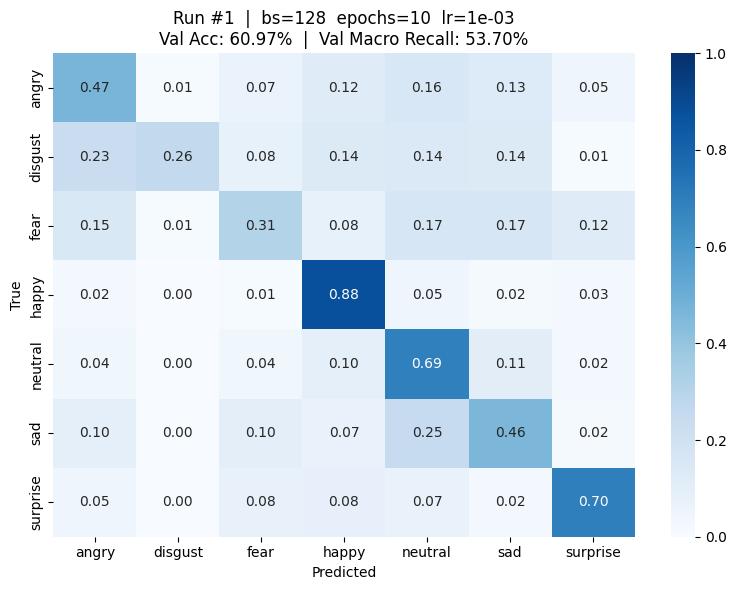

  Confusion matrix saved → confusion_run01_bs128_ep10_lr1e-03.png
Run #2  Config: {'batch_size': 512, 'num_epochs': 10, 'lr': 0.001}


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

  Epoch 1/10  Train Acc: 47.84%
  Epoch 2/10  Train Acc: 56.10%
  Epoch 3/10  Train Acc: 58.11%
  Epoch 4/10  Train Acc: 59.21%
  Epoch 5/10  Train Acc: 59.88%
  Epoch 6/10  Train Acc: 60.44%
  Epoch 7/10  Train Acc: 60.94%
  Epoch 8/10  Train Acc: 61.09%
  Epoch 9/10  Train Acc: 61.48%
  Epoch 10/10  Train Acc: 61.90%
  → Val Acc: 60.43%  |  Val Macro Recall: 51.39%  |  Time: 18.3 min


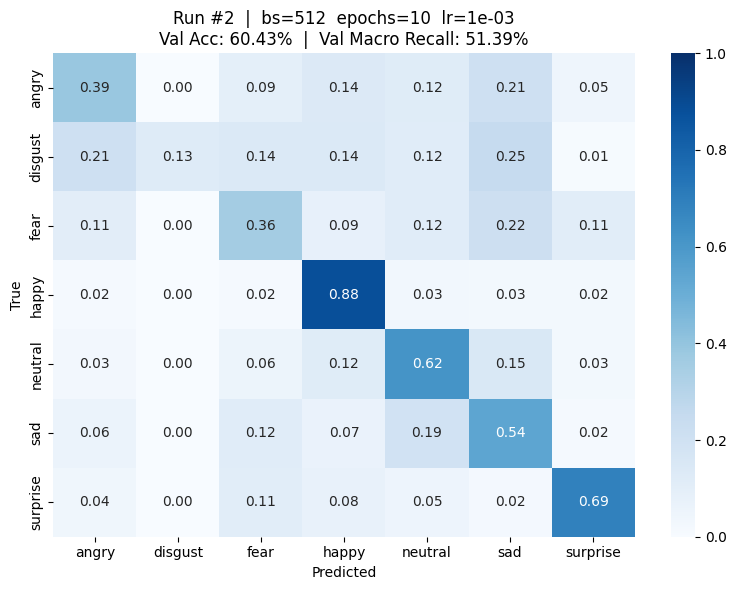

  Confusion matrix saved → confusion_run02_bs512_ep10_lr1e-03.png

GRID SEARCH COMPLETE — ranked by val accuracy
  #     Acc   Recall    Time    BS  Epochs      LR
-------------------------------------------------------
# 1  60.97%   53.70%   18.2m   128      10  1e-03
# 2  60.43%   51.39%   18.3m   512      10  1e-03


In [ ]:
import os, itertools, time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTImageProcessor
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, recall_score
# from torch.cuda.amp import GradScaler, autocast

# ---------------------GRID OF HYPERPARAMETERS
GRID = {
    # "batch_size": [32, 64, 128, 512],
    "batch_size": [32],
    "num_epochs": [10],
    # "num_epochs": [5, 10],
    # "lr":         [2e-4, 5e-4, 1e-3],
    "lr":         [1e-3],
}

# Fixed settings (not worth sweeping)
FREEZE_BASE  = True   # always freeze — pretrained backbone is already excellent
WEIGHT_DECAY = 1e-2   # sensible default; barely matters when only training 1 layer
NUM_WORKERS  = 2
MODEL_NAME   = "google/vit-base-patch16-224"
EMOTION_LABELS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
EMOTIONS       = {i: label for i, label in enumerate(EMOTION_LABELS)}

#  --------------------- DATA PREPARATION
#  data loading
path = kagglehub.dataset_download("jonathanoheix/face-expression-recognition-dataset")
for root, dirs, files in os.walk(path):
    if "train" in dirs and "validation" in dirs:
        train_dir = os.path.join(root, "train")
        val_dir   = os.path.join(root, "validation")
        break

#  data preprocessing
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset   = ImageFolder(root=val_dir,   transform=transform)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Total combinations: {len(list(itertools.product(*GRID.values())))}\n")


# --------------------- HELPER FUNCTIONS (evaluate(), confusionMatrix)
def evaluate(model, loader):
    """Returns accuracy, macro recall, and raw predictions/labels for the full loader."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits
            total_loss += criterion(outputs, labels).item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc    = 100 * (all_preds == all_labels).mean()
    # macro recall = average recall across all 7 classes (treats each class equally)
    recall = 100 * recall_score(all_labels, all_preds, average="macro", zero_division=0)

    return acc, recall, total_loss / len(loader), all_preds, all_labels


def plot_confusion_matrix(all_preds, all_labels, config, val_acc, val_recall, run_idx):
    """Saves a seaborn heatmap of the confusion matrix for one config."""
    cm = confusion_matrix(all_labels, all_preds)

    # Normalise each row → shows recall per class (what fraction of true X was predicted correctly)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_norm,
        annot=True,          # show numbers in each cell
        fmt=".2f",           # 2 decimal places
        cmap="Blues",
        xticklabels=EMOTION_LABELS,
        yticklabels=EMOTION_LABELS,
        vmin=0, vmax=1,
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(
        f"Run #{run_idx}  |  bs={config['batch_size']}  epochs={config['num_epochs']}  lr={config['lr']:.0e}\n"
        f"Val Acc: {val_acc:.2f}%  |  Val Macro Recall: {val_recall:.2f}%"
    )
    plt.tight_layout()
    fname = f"confusion_run{run_idx:02d}_bs{config['batch_size']}_ep{config['num_epochs']}_lr{config['lr']:.0e}.png"
    plt.savefig(fname, dpi=120)
    plt.show()
    plt.close()
    print(f"  Confusion matrix saved → {fname}")


# =============================================================================
# 2. GRID SEARCH
# =============================================================================

results  = []
keys     = list(GRID.keys())
values   = list(GRID.values())
criterion = nn.CrossEntropyLoss()   # defined here so evaluate() can use it

for run_idx, combo in enumerate(itertools.product(*values), start=1):
    config = dict(zip(keys, combo))

    print("=" * 60)
    print(f"Run #{run_idx}  Config: {config}")

    # ── DataLoaders ───────────────────────────────────────────────────────────
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"],
                              shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=config["batch_size"],
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # ── Fresh model for every run ─────────────────────────────────────────────
    model = ViTForImageClassification.from_pretrained(MODEL_NAME)
    model.classifier = nn.Linear(model.config.hidden_size, 7)
    model.config.num_labels = 7
    model.config.id2label   = EMOTIONS

    if FREEZE_BASE:
        for param in model.base_model.parameters():
            param.requires_grad = False

    model = model.to(device)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"],
        weight_decay=WEIGHT_DECAY
    )

    # ── Training loop ─────────────────────────────────────────────────────────
    start_time = time.time()
    # scaler = GradScaler()
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(config["num_epochs"]):
        model.train()
        train_loss, train_correct = 0.0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            # outputs = model(pixel_values=images).logits
            # loss    = criterion(outputs, labels)
            # optimizer.zero_grad()
            # loss.backward()
            # optimizer.step()

            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values=images).logits
                loss    = criterion(outputs, labels)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()


            train_loss    += loss.item()
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()

        # Quick per-epoch print (no full eval pass — keeps training fast)
        train_acc = 100 * train_correct / len(train_dataset)
        print(f"  Epoch {epoch+1}/{config['num_epochs']}  Train Acc: {train_acc:.2f}%")

    # ── evaluate() after model training ─────────────────────────────────────
    val_acc, val_recall, val_loss, all_preds, all_labels = evaluate(model, val_loader)
    elapsed = time.time() - start_time

    print(f"  → Val Acc: {val_acc:.2f}%  |  Val Macro Recall: {val_recall:.2f}%  |  Time: {elapsed/60:.1f} min")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    plot_confusion_matrix(all_preds, all_labels, config, val_acc, val_recall, run_idx)

    results.append({
        **config,
        "val_acc":    round(val_acc, 2),
        "val_recall": round(val_recall, 2),
        "time_min":   round(elapsed / 60, 1)
    })

# =============================================================================
# 3. SUMMARY — sorted by best validation accuracy
# =============================================================================

print("\n" + "=" * 60)
print("GRID SEARCH COMPLETE — ranked by val accuracy")
print("=" * 60)
print(f"{'#':>3}  {'Acc':>6}  {'Recall':>7}  {'Time':>6}  {'BS':>4}  {'Epochs':>6}  {'LR':>6}")
print("-" * 55)

results.sort(key=lambda x: x["val_acc"], reverse=True)
for i, r in enumerate(results, 1):
    print(f"#{i:>2}  {r['val_acc']:>5.2f}%  {r['val_recall']:>6.2f}%  {r['time_min']:>5.1f}m  "
          f"{r['batch_size']:>4}  {r['num_epochs']:>6}  {r['lr']:.0e}")